# Loading and Visualizing Data
### Assignment — CDP Mapping Systems, Columbia GSAPP

**Dataset:** [2015 Street Tree Census — Tree Data](https://data.cityofnewyork.us/Environment/2015-Street-Tree-Census-Tree-Data/uvpi-gqnh) (NYC Open Data, published by NYC Parks & Recreation / NYC DoITT)

**Author:** *[your name here]*

---

## Why this dataset

I chose the **2015 Street Tree Census** for three reasons:

1. **Relevance to a possible colloquium topic.** Street trees are one of the most visible, unevenly-distributed pieces of "green infrastructure" in New York City. Canopy cover has been linked in the environmental-justice literature to heat exposure, air quality, and stormwater management — themes I want to keep exploring for my colloquium project.
2. **Data richness.** Unlike many one-off NYC Open Data tables, the Tree Census is a completed, borough-wide census (not a sample) with ~683,000 individually geolocated trees, each carrying both a *condition* attribute (`health`) and a *size* attribute (`tree_dbh`, diameter at breast height), plus species, stewardship, and administrative geography fields (borough, community board, council district, census tract, Neighborhood Tabulation Area).
3. **A genuine "can/cannot" story.** The dataset looks authoritative (it is a full census, not a survey), but as I'll show below, several of its most interesting fields are *subjective, single-point-in-time, and spatially biased* — which makes it a good vehicle for practicing the kind of critical reading of attributes that this assignment asks for.

## What I'll do in this notebook

1. Load the data directly from the NYC Open Data Socrata API (no manual download required).
2. Explore the dataset's metadata, schema, and attribute distributions.
3. Focus on two attributes: **`health`** (categorical — Good / Fair / Poor) and **`tree_dbh`** (continuous — trunk diameter in inches).
4. Build both **non-map** (bar chart, histogram, boxplot) and **map** (point map + choropleth by neighborhood) visualizations of these attributes.
5. Close with a written, numeric, and graphical discussion of what `health` and `tree_dbh` can and cannot tell us about the urban forest.


## 1. Setup

Following the pattern from the *Vector Data APIs* tutorial, we import the "bare minimum" for tabular/geospatial work, plus a couple of extras for pulling data straight from an API and for nicer choropleth classification.


In [3]:
# the bare minimum
import io
import time

import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LogNorm

# classification / color help (same libraries used in the Comparing Census
# Variables and Vector Data APIs tutorials)
import mapclassify
from palettable.colorbrewer.sequential import YlOrRd_9, PuBu_9
from palettable.colorbrewer.qualitative import Set2_3

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.facecolor"] = "white"


## 2. Load the data

NYC Open Data serves this dataset through the **Socrata Open Data API (SODA)**. Rather than downloading a static CSV by hand, we hit the API directly — this keeps the notebook reproducible and mirrors the "Vector Data APIs" workflow from the tutorials, except here we query a REST endpoint instead of reading a local shapefile.

The Socrata API caps a single request at a few thousand rows unless you page through results with `$limit`/`$offset`, so I wrote a small helper, `fetch_all()`, that pages through the full ~683,000-row table. (An app token isn't required for this volume of traffic, but if you hit rate limits, register a free token at [Socrata](https://data.cityofnewyork.us/profile/edit/developer_settings) and pass it as a header.)

For the purposes of exploration, I only request the columns we'll actually use — this keeps the transfer fast and the dataframe manageable in memory.


In [5]:
SOCRATA_DOMAIN = "data.cityofnewyork.us"
TREES_DATASET_ID = "uvpi-gqnh"  # 2015 Street Tree Census - Tree Data
TREES_URL = f"https://{SOCRATA_DOMAIN}/resource/{TREES_DATASET_ID}.json"

# Only pull the fields we need for this assignment.
FIELDS = [
    "tree_id",
    "status",
    "health",
    "spc_common",
    "tree_dbh",
    "steward",
    "boroname",
    "nta",
    "nta_name",
    "zipcode",
    "latitude",
    "longitude",
]


def fetch_all(url, select_fields, where=None, page_size=50000, app_token=None):
    """Page through a Socrata (SODA) endpoint and return one concatenated DataFrame.

    Socrata limits a single response to a modest number of rows by default,
    so we repeatedly request `page_size` rows at increasing `$offset` values
    until a page comes back with fewer rows than requested (i.e., we've
    reached the end of the table).
    """
    headers = {"X-App-Token": app_token} if app_token else {}
    frames = []
    offset = 0

    while True:
        params = {
            "$select": ",".join(select_fields),
            "$limit": page_size,
            "$offset": offset,
        }
        if where:
            params["$where"] = where

        resp = requests.get(url, params=params, headers=headers, timeout=60)
        resp.raise_for_status()
        page = pd.DataFrame(resp.json())

        if page.empty:
            break

        frames.append(page)
        offset += page_size

        # be polite to the (free, unauthenticated) API
        time.sleep(0.2)

        if len(page) < page_size:
            break

    return pd.concat(frames, ignore_index=True)


trees_raw = fetch_all(TREES_URL, FIELDS)
trees_raw.shape


(683788, 12)

In [6]:
trees_raw.head()


,tree_id,status,health,spc_common,tree_dbh,steward,boroname,nta,nta_name,zipcode,latitude,longitude
0,180683,Alive,Fair,red maple,3,None,Queens,QN17,Forest Hills,11375,40.72309177,-73.84421522
1,200540,Alive,Fair,pin oak,21,None,Queens,QN49,Whitestone,11357,40.79411067,-73.81867946
2,204026,Alive,Good,honeylocust,3,1or2,Brooklyn,BK90,East Williamsburg,11211,40.71758074,-73.9366077
3,204337,Alive,Good,honeylocust,10,None,Brooklyn,BK90,East Williamsburg,11211,40.71353749,-73.93445616
4,189565,Alive,Good,American linden,21,None,Brooklyn,BK37,Park Slope-Gowanus,11215,40.66677776,-73.97597938


## 3. Basic cleaning and typing

The Socrata JSON API returns every field as a string. Before we can explore or plot the data, we need to cast the numeric fields (`tree_dbh`, `latitude`, `longitude`, `zipcode`) to actual numeric dtypes, and take a look at what data quality issues (missing values, "stump"/"dead" trees with no health rating, etc.) we need to be aware of.


In [7]:
trees = trees_raw.copy()

numeric_cols = ["tree_dbh", "latitude", "longitude", "zipcode"]
for c in numeric_cols:
    trees[c] = pd.to_numeric(trees[c], errors="coerce")

trees.dtypes


tree_id        object
status         object
health         object
spc_common     object
tree_dbh        int64
steward        object
boroname       object
nta            object
nta_name       object
zipcode         int64
latitude      float64
longitude     float64
dtype: object

In [8]:
# how many rows, and how much is missing, for the fields we care about?
trees[["status", "health", "tree_dbh", "spc_common", "boroname", "nta_name"]].isna().mean().round(
    3
) * 100


status        0.0
health        4.6
tree_dbh      0.0
spc_common    4.6
boroname      0.0
nta_name      0.0
dtype: float64

In [9]:
# `health` is only populated for trees that are alive. Dead trees and stumps
# make up a small share of the census but have no health rating -- this is
# our first hint that `health` is a conditional, not universal, attribute.
trees["status"].value_counts(dropna=False)


status
Alive    652173
Stump     17654
Dead      13961
Name: count, dtype: int64

In [10]:
# For the rest of the notebook we focus on *living* trees, since `health`
# and `tree_dbh` are only meaningful (and mostly only present) for them.
living_trees = trees[trees["status"] == "Alive"].copy()
living_trees.shape


(652173, 12)

## 4. Exploring the dataset's metadata and attributes

Before focusing on any one attribute, it's worth getting a general feel for the dataset's shape. The full schema (available in the [NYC Open Data column metadata](https://data.cityofnewyork.us/Environment/2015-Street-Tree-Census-Tree-Data/uvpi-gqnh)) has 45 columns; we only pulled 12. Even within that subset there's a lot going on: administrative geography (`boroname`, `nta`, `zipcode`), a biological attribute (`spc_common`, the species), a stewardship attribute (`steward`, whether a nearby resident/business cares for the tree), and the two attributes I'll focus on: `health` and `tree_dbh`.


In [11]:
living_trees.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tree_id,652173,652173,180683,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,652173,1,Alive,652173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
health,652172,3,Good,528850,NaN,NaN,NaN,NaN,NaN,NaN,NaN
spc_common,652168,132,London planetree,87014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tree_dbh,652173.0,NaN,NaN,NaN,11.709485,8.634239,0.0,5.0,10.0,16.0,425.0
steward,652173,4,None,487823,NaN,NaN,NaN,NaN,NaN,NaN,NaN
boroname,652173,5,Queens,237974,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nta,652173,188,SI01,12530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nta_name,652173,188,Annadale-Huguenot-Prince's Bay-Eltingville,12530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zipcode,652173.0,NaN,NaN,NaN,10914.407958,656.868397,83.0,10314.0,11214.0,11365.0,11697.0


In [12]:
living_trees["boroname"].value_counts()


boroname
Queens           237974
Brooklyn         169744
Staten Island    101443
Bronx             80585
Manhattan         62427
Name: count, dtype: int64

In [13]:
# The 10 most common street tree species citywide
living_trees["spc_common"].value_counts().head(10)


spc_common
London planetree     87014
honeylocust          64263
Callery pear         58931
pin oak              53185
Norway maple         34189
littleleaf linden    29742
cherry               29279
Japanese zelkova     29258
ginkgo               21024
Sophora              19338
Name: count, dtype: int64

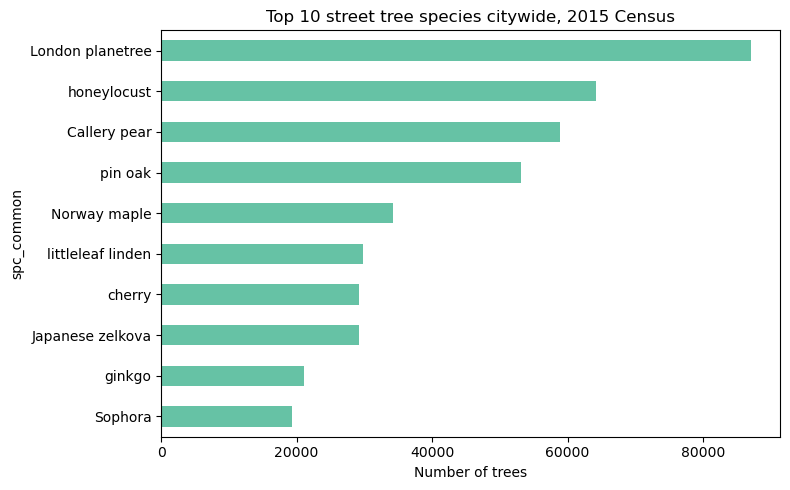

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
living_trees["spc_common"].value_counts().head(10).sort_values().plot.barh(
    ax=ax, color=Set2_3.mpl_colors[0]
)
ax.set_xlabel("Number of trees")
ax.set_title("Top 10 street tree species citywide, 2015 Census")
plt.tight_layout()
plt.show()


## 5. Choosing attributes: `health` and `tree_dbh`

Out of the dataset's many columns, I chose to focus on:

- **`health`** — a categorical field (Good / Fair / Poor) assigned by the census-taker at the time of survey, meant to capture the tree's overall condition (canopy density, evidence of disease/damage, etc.).
- **`tree_dbh`** — trunk diameter at breast height, in inches, a standard forestry proxy for tree size and (loosely) age/maturity.

I picked this pair because they answer two *different* questions that are easy to conflate: `health` tells us something about a tree's *current condition*, while `tree_dbh` tells us about its *physical development*. A large, mature tree can be in poor health, and a small, newly-planted tree can be in excellent health — so looking at them together, rather than assuming one implies the other, is itself an interesting test of the data.

Both fields are also directly relevant to environmental-justice framing: canopy condition and tree size both affect the shade, cooling, and stormwater-interception benefits a block receives, so unevenness in `health` or `tree_dbh` across neighborhoods is a reasonable (if imperfect — see Section 8) proxy for unevenness in tree-based environmental benefits.


## 6. Non-map visualizations

### 6.1 Distribution of `health`


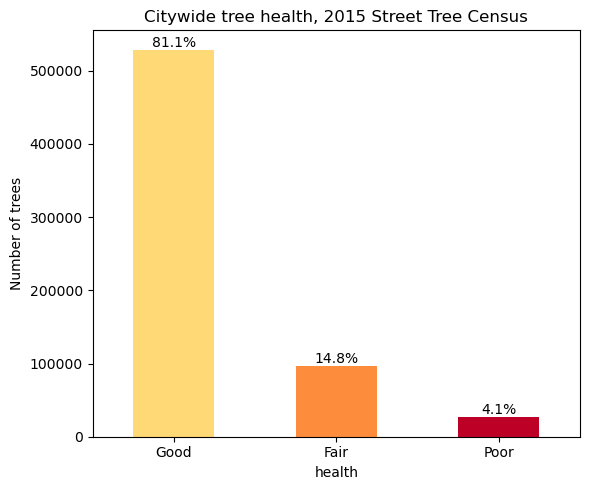

health
Good    81.1
Fair    14.8
Poor     4.1
Name: count, dtype: float64

In [15]:
health_order = ["Good", "Fair", "Poor"]
health_counts = living_trees["health"].value_counts().reindex(health_order)
health_share = (health_counts / health_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 5))
health_counts.plot.bar(ax=ax, color=[YlOrRd_9.mpl_colors[2], YlOrRd_9.mpl_colors[4], YlOrRd_9.mpl_colors[7]])
for i, (count, share) in enumerate(zip(health_counts, health_share)):
    ax.text(i, count, f"{share}%", ha="center", va="bottom")
ax.set_ylabel("Number of trees")
ax.set_title("Citywide tree health, 2015 Street Tree Census")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

health_share


The vast majority of living street trees (roughly 80%) are rated "Good," with health declining sharply from there. This right-skew is worth remembering when we map the data: a neighborhood with, say, twice the citywide share of "Poor" trees is still likely a small absolute number of trees, so small-sample noise can matter at fine geographies (an issue we return to in Section 8).

### 6.2 Distribution of `tree_dbh`


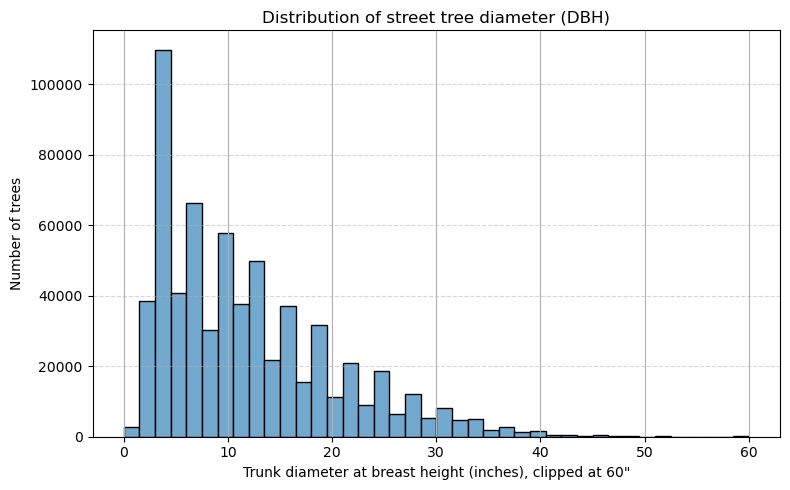

count    652173.000000
mean         11.709485
std           8.634239
min           0.000000
25%           5.000000
50%          10.000000
75%          16.000000
max         425.000000
Name: tree_dbh, dtype: float64

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
living_trees["tree_dbh"].clip(upper=60).hist(bins=40, ax=ax, edgecolor="black", color=PuBu_9.mpl_colors[4])
ax.set_xlabel("Trunk diameter at breast height (inches), clipped at 60\"")
ax.set_ylabel("Number of trees")
ax.set_title("Distribution of street tree diameter (DBH)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

living_trees["tree_dbh"].describe()


`tree_dbh` is heavily right-skewed: the median tree is only about 9–10 inches in diameter (a relatively young or slow-growing tree), while a long tail of large, mature trees stretches out past 40–50 inches. A small number of implausible outliers (>100") likely reflect data-entry or measurement errors and would need to be screened before any rigorous forestry analysis.

### 6.3 Does DBH relate to health?


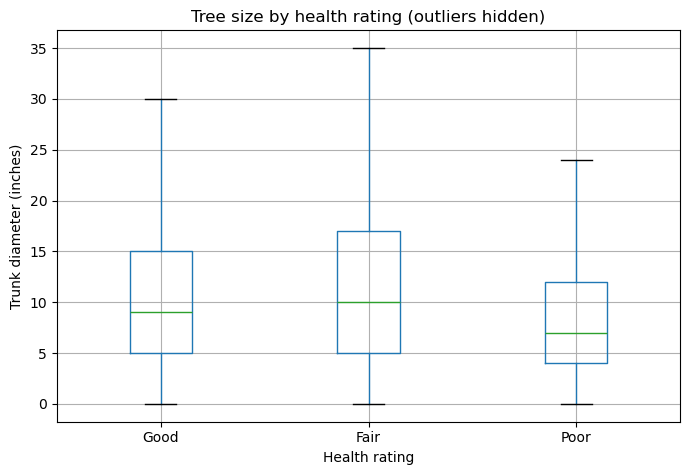

health
Good    10.0
Fair     9.0
Poor     7.0
Name: tree_dbh, dtype: float64

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
living_trees.boxplot(
    column="tree_dbh",
    by="health",
    ax=ax,
    positions=[health_order.index(h) for h in health_order],
    showfliers=False,
)
ax.set_xticks(range(len(health_order)))
ax.set_xticklabels(health_order)
ax.set_xlabel("Health rating")
ax.set_ylabel("Trunk diameter (inches)")
ax.set_title("Tree size by health rating (outliers hidden)")
plt.suptitle("")
plt.tight_layout()
plt.show()

living_trees.groupby("health")["tree_dbh"].median().reindex(health_order)


Median DBH is fairly similar across health categories — "Poor" trees are not dramatically smaller or larger than "Good" ones. This is an early, graphical piece of evidence that **`health` and `tree_dbh` are largely independent attributes**: a tree's condition, as visually assessed by a census-taker, is not simply a function of how big it has grown. We'll come back to this when discussing what each attribute can and cannot tell us.


## 7. Map visualizations

### 7.1 A point map of tree health

With ~650,000 living trees, plotting every single point at full opacity would produce an unreadable, over-plotted mass. Following the same logic the *Vector Data APIs* tutorial used for MapPLUTO ("drawing >800,000 polygons is resource intensive and hard to discern"), I first build a GeoDataFrame from the lat/lon coordinates, then draw a borough at a time with small, semi-transparent markers so that density differences remain visible.


In [18]:
geometry = gpd.points_from_xy(living_trees["longitude"], living_trees["latitude"])
trees_gdf = gpd.GeoDataFrame(living_trees, geometry=geometry, crs="EPSG:4326")
trees_gdf = trees_gdf.dropna(subset=["geometry", "health"])
trees_gdf = trees_gdf[~trees_gdf.geometry.is_empty]
trees_gdf.shape


(652172, 13)

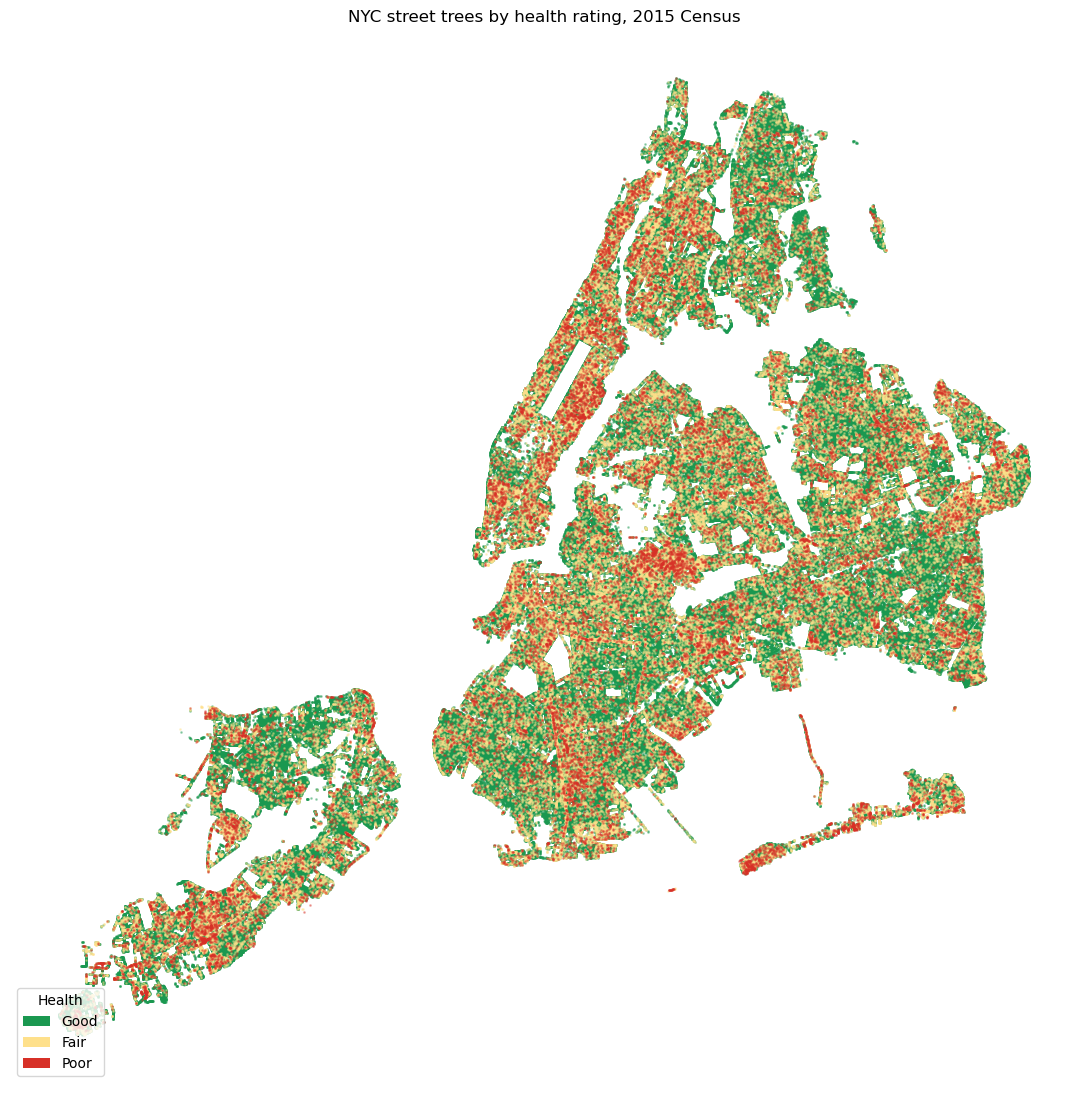

In [19]:
health_colors = {
    "Good": "#1a9850",
    "Fair": "#fee08b",
    "Poor": "#d73027",
}

fig, ax = plt.subplots(figsize=(11, 11))
for h in ["Good", "Fair", "Poor"]:  # draw Good first so Poor/Fair remain visible on top
    subset = trees_gdf[trees_gdf["health"] == h]
    subset.plot(ax=ax, markersize=1, alpha=0.35, color=health_colors[h], label=h)

ax.set_axis_off()
ax.set_title("NYC street trees by health rating, 2015 Census")
legend_handles = [
    Patch(facecolor=c, edgecolor="none", label=h) for h, c in health_colors.items()
]
ax.legend(handles=legend_handles, title="Health", loc="lower left")
plt.tight_layout()
plt.show()


At the citywide point-map scale, the borough-level *pattern of tree planting itself* (dense grid in Manhattan and inner boroughs, sparser and more irregular coverage in eastern Queens and Staten Island) dominates what we see — individual "Poor" (red) trees are hard to distinguish from the surrounding "Good" (green) canopy because there are simply so many more Good trees everywhere. This is a good illustration of why a raw point map is often not the most effective way to compare *rates* across places — for that, we need to aggregate.

### 7.2 Aggregating to neighborhoods (NTAs) for a choropleth

To see *where* poor tree health and larger/smaller trees are concentrated, we aggregate points to NYC's **Neighborhood Tabulation Areas (NTAs)** and compute, per neighborhood: the share of trees rated "Poor," and the median DBH. We pull the NTA boundaries the same way we pulled the tree data — directly from the Socrata API, this time as GeoJSON.


In [22]:
NTA_DATASET_ID = "9nt8-h7nd"  # 2020 Neighborhood Tabulation Areas (NTA)
NTA_URL = f"https://{SOCRATA_DOMAIN}/resource/{NTA_DATASET_ID}.geojson"

resp = requests.get(NTA_URL, params={"$limit": 300}, timeout=60)
resp.raise_for_status()
nta_boundaries = gpd.GeoDataFrame.from_features(resp.json(), crs="EPSG:4326")
nta_boundaries = nta_boundaries.rename(columns={"nta2020": "nta", "ntaname": "nta_name"})
nta_boundaries[["nta", "nta_name", "geometry"]].head()


,nta,nta_name,geometry
0,BK0101,Greenpoint,"MULTIPOLYGON (((-73.93213 40.72816, -73.93238 ..."
1,BK0102,Williamsburg,"MULTIPOLYGON (((-73.95814 40.7244, -73.95772 4..."
2,BK0103,South Williamsburg,"MULTIPOLYGON (((-73.95024 40.70547, -73.94984 ..."
3,BK0104,East Williamsburg,"MULTIPOLYGON (((-73.92406 40.71411, -73.92404 ..."
4,BK0201,Brooklyn Heights,"MULTIPOLYGON (((-73.99236 40.68969, -73.99436 ..."


In [26]:
# Use a spatial join to assign each tree point to the NTA polygon that contains it.
# This avoids relying on potentially mismatched `nta` codes between the tree data
# and the NTA boundary dataset.
trees_with_nta = gpd.sjoin(
    trees_gdf,
    nta_boundaries[["nta", "nta_name", "geometry"]],
    how="inner",
    predicate="within",
)

nta_summary = (
    trees_with_nta.groupby("nta_right")
    .agg(
        n_trees=("tree_id", "count"),
        pct_poor=("health", lambda s: (s == "Poor").mean() * 100),
        median_dbh=("tree_dbh", "median"),
    )
    .reset_index()
    .rename(columns={"nta_right": "nta"})
)

# drop neighborhoods with very few sampled trees -- percentages computed on
# tiny denominators are noisy and can mislead a reader (see Section 8)
nta_summary = nta_summary[nta_summary["n_trees"] >= 50]

nta_map = nta_boundaries.merge(nta_summary, on="nta", how="inner")
nta_map.shape

(235, 15)

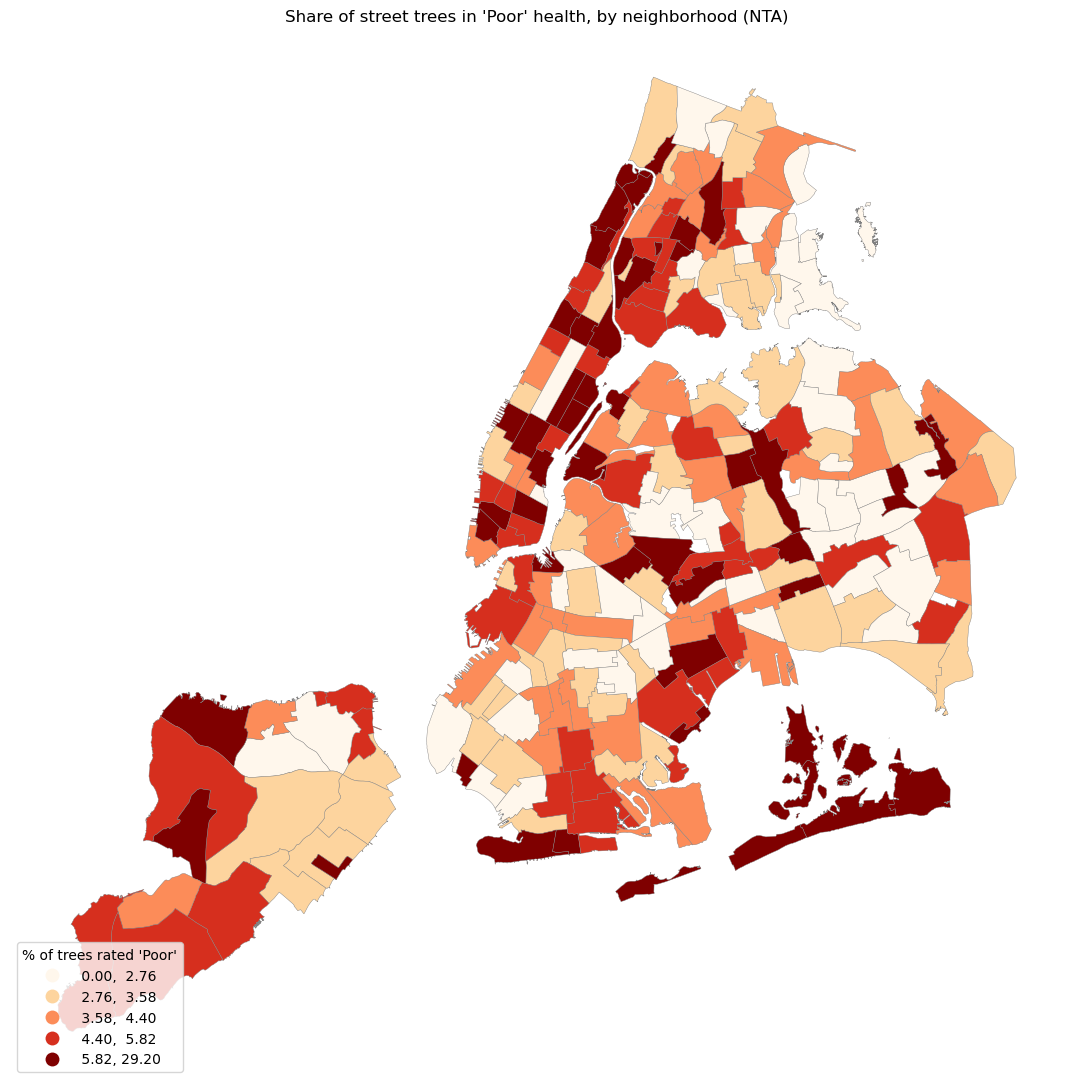

In [27]:
fig, ax = plt.subplots(figsize=(11, 11))
nta_map.plot(
    column="pct_poor",
    scheme="quantiles",
    k=5,
    cmap="OrRd",
    linewidth=0.3,
    edgecolor="grey",
    legend=True,
    legend_kwds={"title": "% of trees rated 'Poor'", "loc": "lower left"},
    ax=ax,
)
ax.set_axis_off()
ax.set_title("Share of street trees in 'Poor' health, by neighborhood (NTA)")
plt.tight_layout()
plt.show()


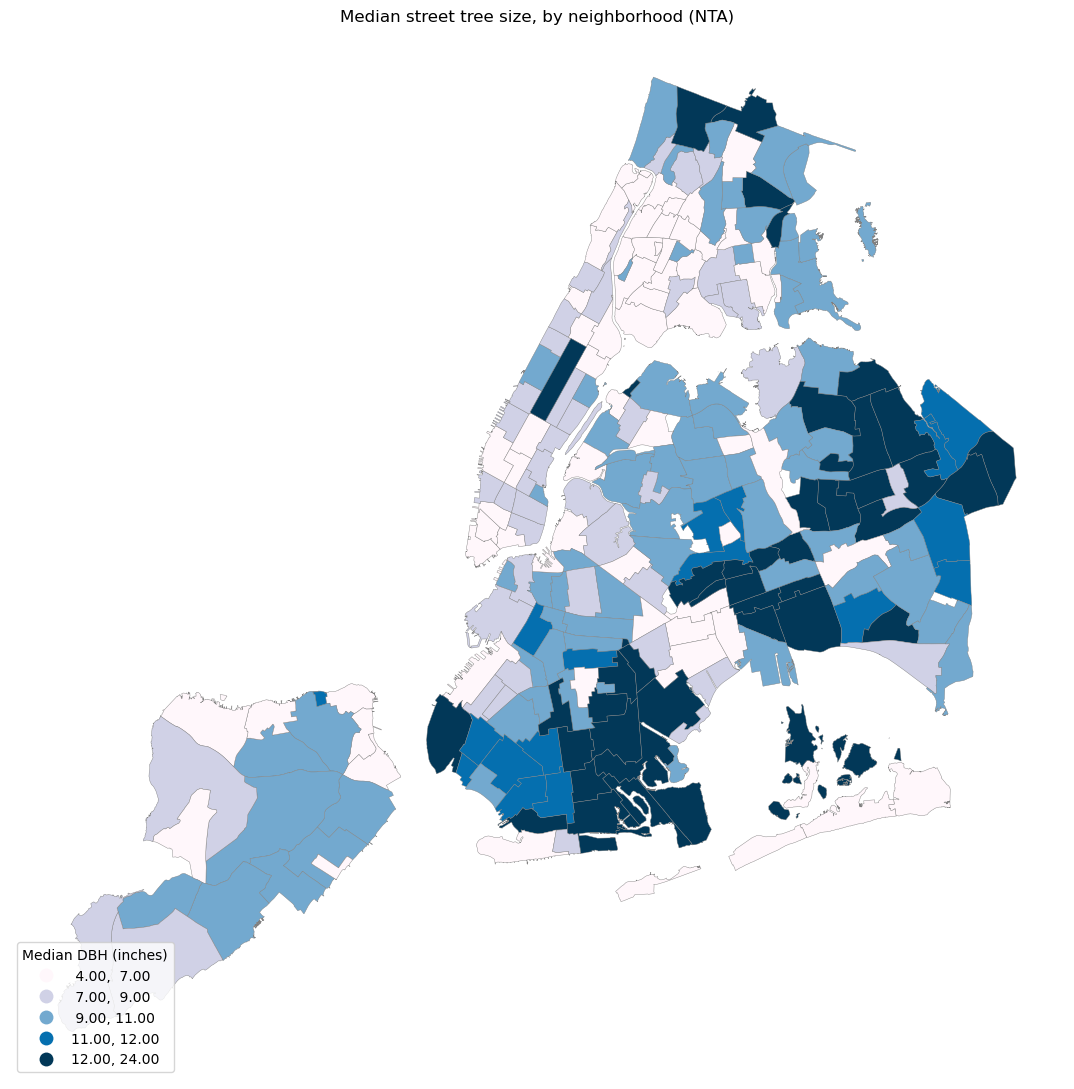

In [28]:
fig, ax = plt.subplots(figsize=(11, 11))
nta_map.plot(
    column="median_dbh",
    scheme="quantiles",
    k=5,
    cmap="PuBu",
    linewidth=0.3,
    edgecolor="grey",
    legend=True,
    legend_kwds={"title": "Median DBH (inches)", "loc": "lower left"},
    ax=ax,
)
ax.set_axis_off()
ax.set_title("Median street tree size, by neighborhood (NTA)")
plt.tight_layout()
plt.show()


Two very different geographies emerge:

- **`pct_poor`** tends to be patchy at the neighborhood scale rather than following an obvious borough-wide gradient — consistent with the boxplot finding above that health is not strongly tied to tree size (or, by extension, to any single simple predictor), and more likely reflects a mix of local street conditions, maintenance, and inherent noise in a subjective rating.
- **`median_dbh`** shows a clearer spatial structure: older, lower-density residential neighborhoods with long-established street tree plantings (parts of the outer boroughs) tend to show larger median trunk diameters than newly developed or recently replanted areas, which is consistent with DBH's role as a rough proxy for planting age.

### 7.3 A quick classification check

Because `pct_poor` is a proportion computed from very different tree counts per neighborhood (a classic small-sample problem — see Section 8), it's worth checking how sensitive our quantile map is to the classification scheme itself. `mapclassify` lets us compare schemes quickly.


In [ ]:
for scheme_name, scheme in [
    ("Quantiles", mapclassify.Quantiles(nta_map["pct_poor"], k=5)),
    ("Natural Breaks (Jenks)", mapclassify.NaturalBreaks(nta_map["pct_poor"], k=5)),
    ("Equal Interval", mapclassify.EqualInterval(nta_map["pct_poor"], k=5)),
]:
    print(scheme_name)
    print(scheme)
    print()


The bin edges shift meaningfully between schemes — a neighborhood that reads as "top quintile" under Quantiles may land in a middle bin under Natural Breaks. This is a useful reminder (echoing the *Comparing Census Variables* tutorial) that a choropleth's visual message is partly a product of the classification choice, not the data alone.


## 8. What can — and cannot — `health` and `tree_dbh` tell us?

### What `health` *can* tell us
- A citywide, standardized (three-category) snapshot of visually-assessed tree condition, collected consistently across all five boroughs in a single census cycle (2015–2016).
- A reasonable first-pass screening tool for city forestry operations to prioritize inspection or removal of at-risk trees.
- When aggregated (as in Section 7.2), a rough, comparative signal about which neighborhoods may need more canopy maintenance investment relative to others.

### What `health` *cannot* tell us
- **Why** a tree is rated Poor. The field records a condition category, not a cause — it can't distinguish disease, storm damage, soil compaction, road salt exposure, vandalism, or simple old age.
- **A precise, objective measurement.** Unlike DBH (an instrument reading), `health` is a categorical judgment made by a volunteer or field surveyor at one moment in time; inter-rater consistency across ~683,000 trees and hundreds of survey days is inherently imperfect. NYC Parks' own documentation for the census describes `health` as based on visual assessment of the crown, not a diagnostic evaluation.
- **Anything about change over time.** The 2015 census is a single cross-section. A tree rated "Good" in 2015 could have died or been removed the following week — the dataset can't show trajectories without linking to the 1995 and 2005 censuses (a possible extension, not attempted here).
- **A guaranteed fair comparison across neighborhoods**, because of the small-sample problem illustrated in Section 7.2/7.3: some NTAs have a few hundred trees and others tens of thousands, so a percentage computed from a small denominator can look extreme purely from sampling noise, independent of anything about neighborhood conditions.

### What `tree_dbh` *can* tell us
- A continuous, instrument-measured proxy for tree size, and — within a species — a reasonable rough proxy for age/maturity, useful for estimating canopy volume, carbon sequestration, or stormwater interception at scale.
- A genuinely spatial signal (Section 7.2) that appears to track planting history / neighborhood age more clearly than `health` does.

### What `tree_dbh` *cannot* tell us
- **Age, precisely.** Growth rate varies enormously by species, light access, soil volume, and pruning regime, so the same DBH can correspond to very different tree ages across species (a sidewalk-constrained street tree vs. a park tree of the same species will grow at very different rates).
- **Canopy area or shade benefit directly.** DBH correlates with canopy spread but isn't the same measurement; two trees with identical DBH can have very different crown shapes.
- **Anything about trees that aren't in the census at all** — this dataset only counts street trees in the public right-of-way; it says nothing about private-yard trees, park trees, or informal/volunteer plantings, which can be a substantial share of a neighborhood's total canopy. Any citywide-canopy claim built only from this dataset would be systematically incomplete.

### A numeric summary of these limits


In [ ]:
# Small-sample problem, illustrated numerically: how much does `n_trees`
# vary across the neighborhoods we mapped, and how does that compare to the
# variation in `pct_poor` itself?
print("Distribution of tree counts per NTA:")
print(nta_summary["n_trees"].describe())

print("\nCorrelation between sample size (n_trees) and pct_poor:")
print(nta_summary[["n_trees", "pct_poor"]].corr().iloc[0, 1].round(3))


A weak (small-magnitude) correlation between `n_trees` and `pct_poor` doesn't rule out sampling noise as an explanation for some of the extreme values we saw on the map — it simply means the *most extreme* percentages are not exclusively coming from the smallest neighborhoods. Still, any neighborhood-level ranking built from `pct_poor` should be read as descriptive, not as a precise or causal estimate of true tree condition.


## 9. Conclusion

Loading the 2015 Street Tree Census directly from the Socrata API and pairing a categorical attribute (`health`) with a continuous one (`tree_dbh`) turned out to be a useful way to see how differently two attributes describing "the same" trees can behave: `tree_dbh` is an objective, instrument-based measurement with a fairly interpretable spatial pattern, while `health` is a subjective, single-moment-in-time classification whose neighborhood-level patterns are noisier and harder to explain from the data alone. Both fields are genuinely useful for an environmental-justice framing of urban forestry — but only if their limitations (subjectivity, sampling variance at fine geographies, exclusion of non-street trees, no temporal depth) are made explicit alongside any map or chart built from them.

**Possible extensions** (not attempted here): joining the 1995/2005/2015 tree censuses to study change over time; joining Census tract demographics to formally test canopy-equity relationships; or joining building footprints/land use (as in the *Vector Data APIs* tutorial) to see whether tree health/size correlates with adjacent land use.

---

*A live, interactive version of this analysis could be published as a [Streamlit](https://streamlit.io/) app — if you do so, link it here: `[link]`.*
